In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================================
# Improved Data Preparation Strategy
#
# Strategy:
# - Combine original Training + Testing folders
# - Add careful medical-safe augmentation
# - Only zoom-in augmentation
# - No horizontal flip
# - No rotation
# - No brightness distortion
# - Shuffle
# - Stratified train/validation/test split
# - Create PyTorch DataLoaders
# ============================================================

import os
import random
import copy
import time
import gzip
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score


# ======================
# Reproducibility
# ======================

seed = 101

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = True


# ======================
# Dataset path and labels
# ======================

DATA_DIR = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"

labels = [
    "glioma_tumor",
    "no_tumor",
    "meningioma_tumor",
    "pituitary_tumor"
]

label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

image_size = 224
batch_size = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ======================
# Zoom-in augmentation function
# ======================

def zoom_in_image(image, zoom_range=(0.85, 0.95)):
    """
    Applies cautious zoom-in augmentation.

    This crops a central/random region from the image and resizes it back
    to 224x224. It does not flip, rotate, or change brightness.

    zoom_range:
    - 0.95 = very mild zoom
    - 0.85 = stronger zoom
    """

    width, height = image.size

    crop_scale = random.uniform(zoom_range[0], zoom_range[1])

    crop_width = int(width * crop_scale)
    crop_height = int(height * crop_scale)

    max_left = width - crop_width
    max_top = height - crop_height

    left = random.randint(0, max_left) if max_left > 0 else 0
    top = random.randint(0, max_top) if max_top > 0 else 0

    right = left + crop_width
    bottom = top + crop_height

    image = image.crop((left, top, right, bottom))
    image = image.resize((image_size, image_size), Image.BILINEAR)

    return image


# ======================
# Load, combine, and augment
# ======================

X = []
y = []

augment_per_image = 1
# 1 means each original image gets one zoomed copy.
# Dataset size roughly doubles.
# You can later try 2, but start with 1.

for split in ["Training", "Testing"]:
    for label in labels:
        folder_path = os.path.join(DATA_DIR, split, label)

        for img_name in tqdm(os.listdir(folder_path), desc=f"{split}/{label}"):
            img_path = os.path.join(folder_path, img_name)

            image = Image.open(img_path).convert("RGB")
            image = image.resize((image_size, image_size), Image.BILINEAR)

            # Add original image
            X.append(np.array(image))
            y.append(label_to_idx[label])

            # Add zoom-in augmented image(s)
            for _ in range(augment_per_image):
                aug_image = zoom_in_image(image, zoom_range=(0.85, 0.95))
                X.append(np.array(aug_image))
                y.append(label_to_idx[label])


X = np.array(X)
y = np.array(y)

print("\nCombined + Augmented Dataset")
print("----------------------------")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution after augmentation:")
for label in labels:
    print(label, np.sum(y == label_to_idx[label]))


# ======================
# Shuffle
# ======================

X, y = shuffle(X, y, random_state=seed)


# ======================
# Stratified train/validation/test split
# ======================
# Similar to notebook-style re-splitting, but with validation separated.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=seed,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=seed,
    stratify=y_temp
)

print("\nDataset split:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain class distribution:")
for label in labels:
    print(label, np.sum(y_train == label_to_idx[label]))

print("\nValidation class distribution:")
for label in labels:
    print(label, np.sum(y_val == label_to_idx[label]))

print("\nTest class distribution:")
for label in labels:
    print(label, np.sum(y_test == label_to_idx[label]))


# ======================
# Dataset class
# ======================

class BrainTumorArrayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label


# ======================
# Transform
# ======================
# Since we already performed offline zoom augmentation,
# this transform only converts to tensor and normalizes.
# No extra augmentation here.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ======================
# DataLoaders
# ======================

train_dataset = BrainTumorArrayDataset(X_train, y_train, transform=transform)
val_dataset = BrainTumorArrayDataset(X_val, y_val, transform=transform)
test_dataset = BrainTumorArrayDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders ready.")

Device: cuda


Testing/pituitary_tumor: 100%|██████████| 74/74 [00:02<00:00, 36.70it/s]



Combined + Augmented Dataset
----------------------------
X shape: (6528, 224, 224, 3)
y shape: (6528,)

Class distribution after augmentation:
glioma_tumor 1852
no_tumor 1000
meningioma_tumor 1874
pituitary_tumor 1802

Dataset split:
Train: (5222, 224, 224, 3)
Validation: (653, 224, 224, 3)
Test: (653, 224, 224, 3)

Train class distribution:
glioma_tumor 1481
no_tumor 800
meningioma_tumor 1499
pituitary_tumor 1442

Validation class distribution:
glioma_tumor 185
no_tumor 100
meningioma_tumor 188
pituitary_tumor 180

Test class distribution:
glioma_tumor 186
no_tumor 100
meningioma_tumor 187
pituitary_tumor 180

DataLoaders ready.


In [3]:
# ============================================================
# Shared training and evaluation functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    loss = running_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, macro_f1, all_labels, all_preds


def print_test_results(model_name, y_true, y_pred, test_loss, test_acc, test_f1):
    print(f"\n{model_name} Test Results")
    print("-" * 45)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=labels,
        digits=4,
        zero_division=0
    ))

In [4]:
# ============================================================
# Model 1: CNN Baseline
# ============================================================

class CNNBaseline(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNBaseline, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = CNNBaseline(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn.parameters(),
    lr=1e-4
)

num_epochs = 50

best_val_f1 = 0.0
best_cnn_wts = copy.deepcopy(cnn.state_dict())

cnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        cnn, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        cnn, val_loader, criterion, device
    )

    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
    cnn_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_cnn_wts = copy.deepcopy(cnn.state_dict())
        torch.save(cnn.state_dict(), "/kaggle/working/best_cnn_baseline.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

cnn.load_state_dict(best_cnn_wts)

test_loss, test_acc, test_f1, y_true_cnn, y_pred_cnn = evaluate(
    cnn, test_loader, criterion, device
)

print_test_results(
    "CNN Baseline",
    y_true_cnn,
    y_pred_cnn,
    test_loss,
    test_acc,
    test_f1
)

cnn_results = pd.DataFrame([{
    "model": "CNN Baseline",
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "test_loss": test_loss
}])

cnn_results.to_csv("/kaggle/working/cnn_baseline_results.csv", index=False)
display(cnn_results)

Epoch [1/50] Train Acc: 0.5843 | Val Acc: 0.7060 | Val F1: 0.6973
Epoch [2/50] Train Acc: 0.6926 | Val Acc: 0.7381 | Val F1: 0.7385
Epoch [3/50] Train Acc: 0.7294 | Val Acc: 0.7427 | Val F1: 0.7265
Epoch [4/50] Train Acc: 0.7612 | Val Acc: 0.8116 | Val F1: 0.8080
Epoch [5/50] Train Acc: 0.7874 | Val Acc: 0.8178 | Val F1: 0.8147
Epoch [6/50] Train Acc: 0.8043 | Val Acc: 0.8116 | Val F1: 0.8059
Epoch [7/50] Train Acc: 0.8296 | Val Acc: 0.8576 | Val F1: 0.8549
Epoch [8/50] Train Acc: 0.8478 | Val Acc: 0.8576 | Val F1: 0.8564
Epoch [9/50] Train Acc: 0.8455 | Val Acc: 0.8545 | Val F1: 0.8546
Epoch [10/50] Train Acc: 0.8604 | Val Acc: 0.8714 | Val F1: 0.8704
Epoch [11/50] Train Acc: 0.8694 | Val Acc: 0.8637 | Val F1: 0.8601
Epoch [12/50] Train Acc: 0.8778 | Val Acc: 0.8821 | Val F1: 0.8850
Epoch [13/50] Train Acc: 0.8880 | Val Acc: 0.8943 | Val F1: 0.8966
Epoch [14/50] Train Acc: 0.8947 | Val Acc: 0.8913 | Val F1: 0.8937
Epoch [15/50] Train Acc: 0.9108 | Val Acc: 0.8959 | Val F1: 0.8987
Epoc

,model,test_accuracy,test_macro_f1,test_loss
0,CNN Baseline,0.957121,0.956941,0.107717


In [5]:
# ============================================================
# Model 2: EfficientNet-B0 Dense
# Two-phase fine-tuning
# ============================================================

def create_efficientnet_b0(num_classes=4):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


effnet = create_efficientnet_b0(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()


# ======================
# Phase 1: freeze feature extractor, train classifier head
# ======================

for param in effnet.features.parameters():
    param.requires_grad = False

for param in effnet.classifier.parameters():
    param.requires_grad = True

phase1_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-3,
    weight_decay=1e-2
)

phase1_epochs = 5

print("\nPhase 1: Training classifier head only")
print("-------------------------------------")

for epoch in range(phase1_epochs):
    train_loss, train_acc = train_one_epoch(
        effnet, train_loader, criterion, phase1_optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        effnet, val_loader, criterion, device
    )

    print(
        f"Phase 1 Epoch [{epoch+1}/{phase1_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )


# ======================
# Phase 2: unfreeze top 20 layers
# ======================

for param in effnet.features.parameters():
    param.requires_grad = False

# EfficientNet features is a Sequential block.
# Unfreeze last 20 child modules from features.
feature_children = list(effnet.features.children())

# More practical interpretation:
# unfreeze the later EfficientNet blocks rather than literal individual layers.
# This usually corresponds to the high-level top layers.
for child in feature_children[-3:]:
    for param in child.parameters():
        param.requires_grad = True

for param in effnet.classifier.parameters():
    param.requires_grad = True

phase2_epochs = 20

phase2_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-4,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    phase2_optimizer,
    T_max=phase2_epochs
)

best_val_f1 = 0.0
best_effnet_wts = copy.deepcopy(effnet.state_dict())

effnet_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

print("\nPhase 2: Fine-tuning top EfficientNet layers")
print("--------------------------------------------")

for epoch in range(phase2_epochs):
    train_loss, train_acc = train_one_epoch(
        effnet, train_loader, criterion, phase2_optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        effnet, val_loader, criterion, device
    )

    scheduler.step()

    effnet_history["train_loss"].append(train_loss)
    effnet_history["train_acc"].append(train_acc)
    effnet_history["val_loss"].append(val_loss)
    effnet_history["val_acc"].append(val_acc)
    effnet_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_effnet_wts = copy.deepcopy(effnet.state_dict())
        torch.save(effnet.state_dict(), "/kaggle/working/best_efficientnet_b0.pth")

    print(
        f"Phase 2 Epoch [{epoch+1}/{phase2_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

effnet.load_state_dict(best_effnet_wts)

test_loss, test_acc, test_f1, y_true_effnet, y_pred_effnet = evaluate(
    effnet, test_loader, criterion, device
)

print_test_results(
    "EfficientNet-B0 Dense",
    y_true_effnet,
    y_pred_effnet,
    test_loss,
    test_acc,
    test_f1
)

effnet_results = pd.DataFrame([{
    "model": "EfficientNet-B0 Dense",
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "test_loss": test_loss
}])

effnet_results.to_csv("/kaggle/working/efficientnet_b0_dense_results.csv", index=False)
display(effnet_results)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s] 



Phase 1: Training classifier head only
-------------------------------------
Phase 1 Epoch [1/5] Train Acc: 0.6948 | Val Acc: 0.7994 | Val F1: 0.7968
Phase 1 Epoch [2/5] Train Acc: 0.7758 | Val Acc: 0.8270 | Val F1: 0.8259
Phase 1 Epoch [3/5] Train Acc: 0.7926 | Val Acc: 0.8331 | Val F1: 0.8326
Phase 1 Epoch [4/5] Train Acc: 0.8018 | Val Acc: 0.8392 | Val F1: 0.8370
Phase 1 Epoch [5/5] Train Acc: 0.8100 | Val Acc: 0.8545 | Val F1: 0.8556

Phase 2: Fine-tuning top EfficientNet layers
--------------------------------------------
Phase 2 Epoch [1/20] Train Acc: 0.8642 | Val Acc: 0.9127 | Val F1: 0.9170
Phase 2 Epoch [2/20] Train Acc: 0.9368 | Val Acc: 0.9357 | Val F1: 0.9406
Phase 2 Epoch [3/20] Train Acc: 0.9600 | Val Acc: 0.9632 | Val F1: 0.9659
Phase 2 Epoch [4/20] Train Acc: 0.9751 | Val Acc: 0.9770 | Val F1: 0.9791
Phase 2 Epoch [5/20] Train Acc: 0.9805 | Val Acc: 0.9740 | Val F1: 0.9765
Phase 2 Epoch [6/20] Train Acc: 0.9856 | Val Acc: 0.9740 | Val F1: 0.9759
Phase 2 Epoch [7/20] T

,model,test_accuracy,test_macro_f1,test_loss
0,EfficientNet-B0 Dense,0.995406,0.995979,0.01568


Device: cuda

Dense EfficientNet-B0 Baseline
------------------------------
Test Accuracy: 0.9954
Test Macro F1: 0.9960
Total Sparsity: 0.0000
Conv Sparsity: 0.0000
Model Size: 15.60 MB
Compressed Size: 14.39 MB
Inference Time: 1.1346 ms/image

Structured pruning EfficientNet-B0 at 20%
Pruned 81 Conv2d layers at 20%
Initial Total Sparsity: 0.0000
Initial Conv Sparsity: 0.1999
Epoch [1/25] Train Loss: 0.4232 | Train Acc: 0.8485 Val Loss: 0.2193 | Val Acc: 0.9234 | Val F1: 0.9241
Epoch [2/25] Train Loss: 0.1842 | Train Acc: 0.9370 Val Loss: 0.1200 | Val Acc: 0.9571 | Val F1: 0.9603
Epoch [3/25] Train Loss: 0.1186 | Train Acc: 0.9602 Val Loss: 0.1086 | Val Acc: 0.9587 | Val F1: 0.9623
Epoch [4/25] Train Loss: 0.0799 | Train Acc: 0.9745 Val Loss: 0.0838 | Val Acc: 0.9648 | Val F1: 0.9667
Epoch [5/25] Train Loss: 0.0710 | Train Acc: 0.9770 Val Loss: 0.0722 | Val Acc: 0.9740 | Val F1: 0.9765
Epoch [6/25] Train Loss: 0.0409 | Train Acc: 0.9870 Val Loss: 0.0712 | Val Acc: 0.9724 | Val F1: 0.97

,model,target_pruning,total_sparsity,conv_sparsity,test_accuracy,test_macro_f1,test_loss,model_size_mb,compressed_size_mb,inference_time_ms_per_image,zero_params,total_params,conv_zero_params,conv_total_params
0,EfficientNet-B0 Dense,0.0,0.000000,0.000000,0.995406,0.995979,0.015680,15.596606,14.393881,1.134600,0,4012672,0,3956192
1,EfficientNet-B0 Pruned 20%,0.2,0.197101,0.199915,0.990812,0.990761,0.024962,15.598247,11.838282,1.156240,790903,4012672,790903,3956192
2,EfficientNet-B0 Pruned 40%,0.4,0.394422,0.400053,0.938744,0.937016,0.181605,15.598247,9.224498,1.139164,1582685,4012672,1582685,3956192
3,EfficientNet-B0 Pruned 60%,0.6,0.591503,0.599947,0.889740,0.889974,0.292813,15.598247,6.585227,1.136418,2373507,4012672,2373507,3956192
4,EfficientNet-B0 Pruned 80%,0.8,0.788823,0.800085,0.286371,0.111310,1.363914,15.598247,4.005530,1.152236,3165289,4012672,3165289,3956192



Saved to:
/kaggle/working/efficientnet_b0_report_method_pruning_results.csv


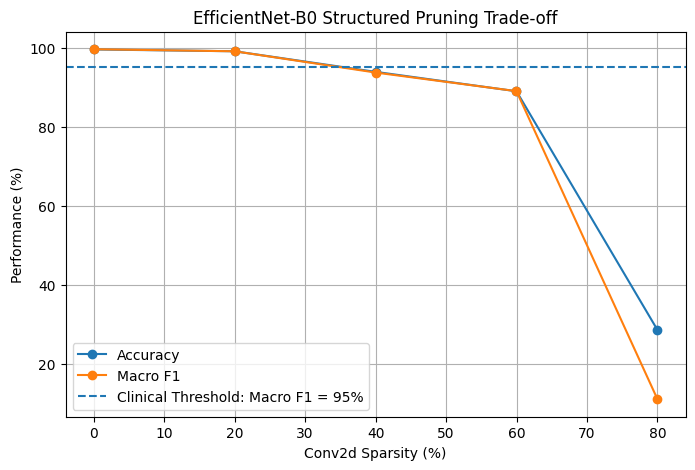

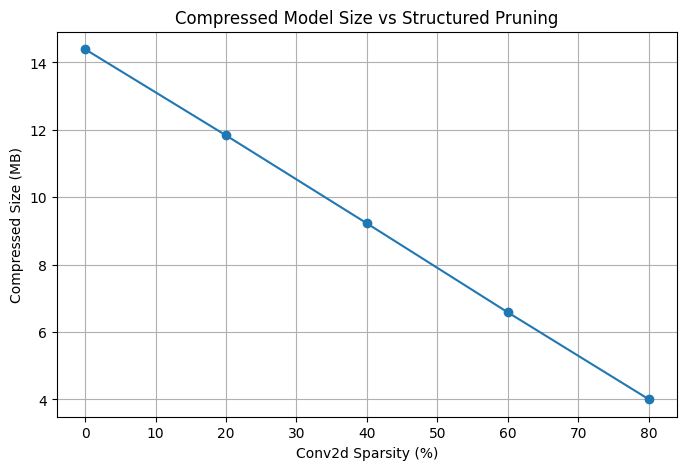

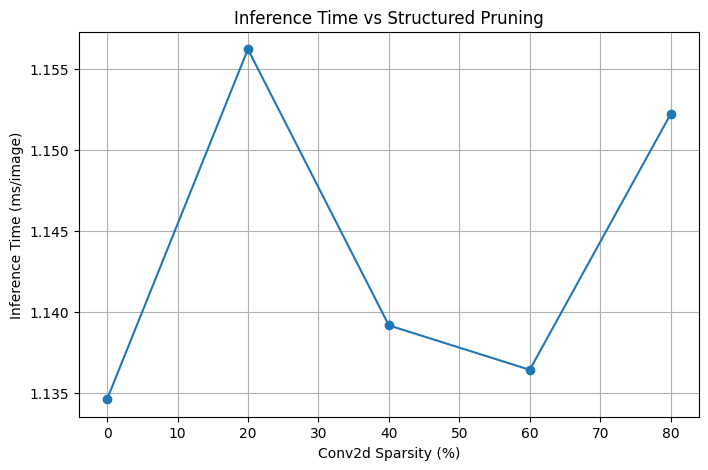


Clinically Viable Models
------------------------


,model,target_pruning,total_sparsity,conv_sparsity,test_accuracy,test_macro_f1,test_loss,model_size_mb,compressed_size_mb,inference_time_ms_per_image,zero_params,total_params,conv_zero_params,conv_total_params
0,EfficientNet-B0 Dense,0.0,0.000000,0.000000,0.995406,0.995979,0.015680,15.596606,14.393881,1.13460,0,4012672,0,3956192
1,EfficientNet-B0 Pruned 20%,0.2,0.197101,0.199915,0.990812,0.990761,0.024962,15.598247,11.838282,1.15624,790903,4012672,790903,3956192



Maximum Clinically Viable Compression
-------------------------------------
Model: EfficientNet-B0 Pruned 20%
Target Pruning: 20%
Conv Sparsity: 19.99%
Total Sparsity: 19.71%
Test Accuracy: 99.08%
Test Macro F1: 99.08%
Compressed Size: 11.84 MB
Inference Time: 1.1562 ms/image


In [6]:
# ============================================================
# Model 3: Structured Weight Pruning
# Report methodology implementation AS SUBMITTED
#
# - L1-norm structured pruning
# - Apply to all Conv2d layers
# - Sparsity levels: 20%, 40%, 60%, 80%
# - Fine-tune each pruned model for 10 epochs
# - Evaluate accuracy, macro F1, model size, inference time
# ============================================================

import os
import copy
import time
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix, f1_score


# ======================
# 1. Settings
# ======================

num_classes = 4
pruning_levels = [0.20, 0.40, 0.60, 0.80]
fine_tune_epochs = 25

dense_model_path = "/kaggle/working/best_efficientnet_b0.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ======================
# 2. Create EfficientNet-B0
# Must match your dense model exactly
# ======================

def create_efficientnet_b0(num_classes=4):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


# ======================
# 3. Report-style structured pruning
# ======================

def apply_report_structured_pruning(model, amount):
    """
    Applies L1-norm structured pruning to every Conv2d layer.

    This follows the submitted report methodology:
    - For each convolutional layer
    - Rank filters by L1 norm
    - Prune bottom s%
    - Use torch.nn.utils.prune.ln_structured
    """

    pruned_layers = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(
                module,
                name="weight",
                amount=amount,
                n=1,
                dim=0
            )
            pruned_layers.append(name)

    print(f"Pruned {len(pruned_layers)} Conv2d layers at {int(amount * 100)}%")
    return model, pruned_layers


def remove_pruning_reparameterization(model):
    """
    Makes pruning permanent after fine-tuning.
    Keeps the zeroed filters zero.
    """

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            try:
                prune.remove(module, "weight")
            except ValueError:
                pass

    return model


# ======================
# 4. Sparsity calculations
# ======================

def calculate_total_sparsity(model):
    total_params = 0
    zero_params = 0

    for param in model.parameters():
        total_params += param.numel()
        zero_params += torch.sum(param == 0).item()

    sparsity = zero_params / total_params if total_params > 0 else 0
    return sparsity, zero_params, total_params


def calculate_conv_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            weight = module.weight
            total_params += weight.numel()
            zero_params += torch.sum(weight == 0).item()

    sparsity = zero_params / total_params if total_params > 0 else 0
    return sparsity, zero_params, total_params


# ======================
# 5. Model size
# ======================

def get_model_size_mb(model, filename):
    torch.save(model.state_dict(), filename)
    return os.path.getsize(filename) / (1024 * 1024)


def get_compressed_model_size_mb(model, filename):
    state_dict = model.state_dict()

    with gzip.open(filename, "wb") as f:
        pickle.dump(state_dict, f)

    return os.path.getsize(filename) / (1024 * 1024)


# ======================
# 6. Inference time
# ======================

def measure_inference_time(model, loader, device, num_batches=20):
    model.eval()

    times = []
    total_images = 0

    # Warm-up
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            if batch_idx >= 3:
                break

            images = images.to(device)
            _ = model(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # Timed inference
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            if batch_idx >= num_batches:
                break

            images = images.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.time()
            _ = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.time()

            times.append(end_time - start_time)
            total_images += images.size(0)

    return (sum(times) / total_images) * 1000


# ======================
# 7. Training and evaluation
# ======================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    loss = running_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, macro_f1, all_labels, all_preds


# ======================
# 8. Dense baseline evaluation
# ======================

criterion = nn.CrossEntropyLoss()

dense_model = create_efficientnet_b0(num_classes=num_classes)
dense_model.load_state_dict(torch.load(dense_model_path, map_location=device))
dense_model = dense_model.to(device)

dense_test_loss, dense_test_acc, dense_test_f1, _, _ = evaluate(
    dense_model,
    test_loader,
    criterion,
    device
)

dense_total_sparsity, dense_zero_params, dense_total_params = calculate_total_sparsity(dense_model)
dense_conv_sparsity, dense_conv_zero_params, dense_conv_total_params = calculate_conv_sparsity(dense_model)

dense_model_size = get_model_size_mb(
    dense_model,
    "/kaggle/working/dense_efficientnet_b0.pth"
)

dense_compressed_size = get_compressed_model_size_mb(
    dense_model,
    "/kaggle/working/dense_efficientnet_b0.pkl.gz"
)

dense_inference_time = measure_inference_time(
    dense_model,
    test_loader,
    device
)

print("\nDense EfficientNet-B0 Baseline")
print("------------------------------")
print(f"Test Accuracy: {dense_test_acc:.4f}")
print(f"Test Macro F1: {dense_test_f1:.4f}")
print(f"Total Sparsity: {dense_total_sparsity:.4f}")
print(f"Conv Sparsity: {dense_conv_sparsity:.4f}")
print(f"Model Size: {dense_model_size:.2f} MB")
print(f"Compressed Size: {dense_compressed_size:.2f} MB")
print(f"Inference Time: {dense_inference_time:.4f} ms/image")


# ======================
# 9. Pruning experiment
# ======================

pruning_results = []

pruning_results.append({
    "model": "EfficientNet-B0 Dense",
    "target_pruning": 0.00,
    "total_sparsity": dense_total_sparsity,
    "conv_sparsity": dense_conv_sparsity,
    "test_accuracy": dense_test_acc,
    "test_macro_f1": dense_test_f1,
    "test_loss": dense_test_loss,
    "model_size_mb": dense_model_size,
    "compressed_size_mb": dense_compressed_size,
    "inference_time_ms_per_image": dense_inference_time,
    "zero_params": dense_zero_params,
    "total_params": dense_total_params,
    "conv_zero_params": dense_conv_zero_params,
    "conv_total_params": dense_conv_total_params
})


for amount in pruning_levels:
    print("\n" + "=" * 70)
    print(f"Structured pruning EfficientNet-B0 at {int(amount * 100)}%")
    print("=" * 70)

    # Load fresh dense model each time
    pruned_model = create_efficientnet_b0(num_classes=num_classes)
    pruned_model.load_state_dict(torch.load(dense_model_path, map_location=device))
    pruned_model = pruned_model.to(device)

    # Apply report-style pruning to all Conv2d layers
    pruned_model, pruned_layers = apply_report_structured_pruning(
        pruned_model,
        amount=amount
    )

    initial_total_sparsity, _, _ = calculate_total_sparsity(pruned_model)
    initial_conv_sparsity, _, _ = calculate_conv_sparsity(pruned_model)

    print(f"Initial Total Sparsity: {initial_total_sparsity:.4f}")
    print(f"Initial Conv Sparsity: {initial_conv_sparsity:.4f}")

    # Fine-tune for 10 epochs, as report states
    optimizer = optim.AdamW(
        pruned_model.parameters(),
        lr=1e-4,
        weight_decay=1e-2
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=fine_tune_epochs
    )

    best_val_f1 = 0.0
    best_model_wts = copy.deepcopy(pruned_model.state_dict())

    for epoch in range(fine_tune_epochs):
        train_loss, train_acc = train_one_epoch(
            pruned_model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            pruned_model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_wts = copy.deepcopy(pruned_model.state_dict())

        print(
            f"Epoch [{epoch+1}/{fine_tune_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )

    # Load best masked model
    pruned_model.load_state_dict(best_model_wts)

    # Make pruning permanent after fine-tuning
    pruned_model = remove_pruning_reparameterization(pruned_model)

    final_total_sparsity, zero_params, total_params = calculate_total_sparsity(pruned_model)
    final_conv_sparsity, conv_zero_params, conv_total_params = calculate_conv_sparsity(pruned_model)

    print(f"\nFinal Total Sparsity: {final_total_sparsity:.4f}")
    print(f"Final Conv Sparsity: {final_conv_sparsity:.4f}")

    # Test evaluation
    test_loss, test_acc, test_f1, y_true_pruned, y_pred_pruned = evaluate(
        pruned_model,
        test_loader,
        criterion,
        device
    )

    model_filename = f"/kaggle/working/efficientnet_b0_pruned_{int(amount * 100)}.pth"
    compressed_filename = f"/kaggle/working/efficientnet_b0_pruned_{int(amount * 100)}.pkl.gz"

    model_size = get_model_size_mb(pruned_model, model_filename)
    compressed_size = get_compressed_model_size_mb(pruned_model, compressed_filename)

    inference_time = measure_inference_time(
        pruned_model,
        test_loader,
        device
    )

    print("\nPruned Model Test Results")
    print("-------------------------")
    print(f"Target Pruning: {int(amount * 100)}%")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")
    print(f"Total Sparsity: {final_total_sparsity:.4f}")
    print(f"Conv Sparsity: {final_conv_sparsity:.4f}")
    print(f"Model Size: {model_size:.2f} MB")
    print(f"Compressed Size: {compressed_size:.2f} MB")
    print(f"Inference Time: {inference_time:.4f} ms/image")

    print("\nClassification Report:")
    print(classification_report(
        y_true_pruned,
        y_pred_pruned,
        target_names=labels,
        digits=4,
        zero_division=0
    ))

    pruning_results.append({
        "model": f"EfficientNet-B0 Pruned {int(amount * 100)}%",
        "target_pruning": amount,
        "total_sparsity": final_total_sparsity,
        "conv_sparsity": final_conv_sparsity,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "test_loss": test_loss,
        "model_size_mb": model_size,
        "compressed_size_mb": compressed_size,
        "inference_time_ms_per_image": inference_time,
        "zero_params": zero_params,
        "total_params": total_params,
        "conv_zero_params": conv_zero_params,
        "conv_total_params": conv_total_params
    })


# ======================
# 10. Save results
# ======================

pruning_df = pd.DataFrame(pruning_results)

pruning_df.to_csv(
    "/kaggle/working/efficientnet_b0_report_method_pruning_results.csv",
    index=False
)

print("\nFinal Report-Method Pruning Results")
print("-----------------------------------")
display(pruning_df)

print("\nSaved to:")
print("/kaggle/working/efficientnet_b0_report_method_pruning_results.csv")


# ======================
# 11. Plot compression-performance curve
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["test_accuracy"] * 100,
    marker="o",
    label="Accuracy"
)
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["test_macro_f1"] * 100,
    marker="o",
    label="Macro F1"
)
plt.axhline(y=95, linestyle="--", label="Clinical Threshold: Macro F1 = 95%")
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Performance (%)")
plt.title("EfficientNet-B0 Structured Pruning Trade-off")
plt.legend()
plt.grid(True)
plt.show()


# ======================
# 12. Plot compressed size
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["compressed_size_mb"],
    marker="o"
)
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Compressed Size (MB)")
plt.title("Compressed Model Size vs Structured Pruning")
plt.grid(True)
plt.show()


# ======================
# 13. Plot inference time
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["inference_time_ms_per_image"],
    marker="o"
)
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Inference Time (ms/image)")
plt.title("Inference Time vs Structured Pruning")
plt.grid(True)
plt.show()


# ======================
# 14. Clinical viability check
# ======================

clinical_threshold = 0.95

viable_models = pruning_df[pruning_df["test_macro_f1"] >= clinical_threshold]

print("\nClinically Viable Models")
print("------------------------")
display(viable_models)

if len(viable_models) > 0:
    best_compressed = viable_models.sort_values(
        by="conv_sparsity",
        ascending=False
    ).iloc[0]

    print("\nMaximum Clinically Viable Compression")
    print("-------------------------------------")
    print(f"Model: {best_compressed['model']}")
    print(f"Target Pruning: {best_compressed['target_pruning'] * 100:.0f}%")
    print(f"Conv Sparsity: {best_compressed['conv_sparsity'] * 100:.2f}%")
    print(f"Total Sparsity: {best_compressed['total_sparsity'] * 100:.2f}%")
    print(f"Test Accuracy: {best_compressed['test_accuracy'] * 100:.2f}%")
    print(f"Test Macro F1: {best_compressed['test_macro_f1'] * 100:.2f}%")
    print(f"Compressed Size: {best_compressed['compressed_size_mb']:.2f} MB")
    print(f"Inference Time: {best_compressed['inference_time_ms_per_image']:.4f} ms/image")
else:
    print("No model met the clinical viability threshold of Macro F1 >= 0.95.")